In [ ]:
# import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# mount google drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# define project paths

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: /content/drive/MyDrive/Brain_Tumor_CNN_Project


In [ ]:
# paths to saved split files

TRAIN_CSV = os.path.join(
    RESULTS_DIR,
    "train_split.csv")

VAL_CSV = os.path.join(
    RESULTS_DIR,
    "validation_split.csv")

# Load the splits
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

Training images  : 7720
Validation images: 1930


In [ ]:
# define the test dataset path

PROJECT_DIR = "/content/drive/MyDrive/Brain_Tumor_CNN_Project"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "Epic and CSCR hospital Dataset"
)

TEST_DIR = os.path.join(DATASET_DIR, "Test")

print("Test directory:", TEST_DIR)
print("Test directory exists:", os.path.exists(TEST_DIR))

Test directory: /content/drive/MyDrive/Brain_Tumor_CNN_Project/dataset/Epic and CSCR hospital Dataset/Test
Test directory exists: True


In [ ]:
# define the preprocessing function again

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

def preprocess_image(image_path, label):

    # Read image
    image = tf.io.read_file(image_path)

    # Decode and convert to 3-channel RGB
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Set image shape
    image.set_shape([None, None, 3])

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixel values to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    # Convert label to float
    label = tf.cast(label, tf.float32)

    return image, label

print("Preprocessing function ready.")

Preprocessing function ready.


In [ ]:
# recreate the training dataset

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=SEED
)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training dataset ready.")

Training dataset ready.


In [ ]:
# recreate the validation dataset

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

val_dataset = val_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Validation dataset ready.")

Validation dataset ready.


In [ ]:
# create the test dataframe

CLASS_MAPPING = {
    "glioma": 1,
    "meningioma": 1,
    "pituitary": 1,
    "notumor": 0
}

test_records = []

for class_name, label in CLASS_MAPPING.items():

    class_dir = os.path.join(TEST_DIR, class_name)

    for filename in os.listdir(class_dir):

        file_path = os.path.join(class_dir, filename)

        if os.path.isfile(file_path):
            test_records.append({
                "image_path": file_path,
                "class_name": class_name,
                "label": label
            })

test_df = pd.DataFrame(test_records)

print("Total test images:", len(test_df))

print("\nTest images by original class:")
print(test_df["class_name"].value_counts())

print("\nTest images by binary label:")
print(test_df["label"].value_counts())

Total test images: 2414

Test images by original class:
class_name
glioma        755
pituitary     626
meningioma    546
notumor       487
Name: count, dtype: int64

Test images by binary label:
label
1    1927
0     487
Name: count, dtype: int64


In [ ]:
# create the TensorFlow test dataset

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Test dataset created successfully.")

Test dataset created successfully.


In [ ]:
# verify one test batch

test_images, test_labels = next(iter(test_dataset))

print("Test image batch shape :", test_images.shape)
print("Test label batch shape :", test_labels.shape)

print("Pixel minimum:", tf.reduce_min(test_images).numpy())
print("Pixel maximum:", tf.reduce_max(test_images).numpy())

Test image batch shape : (32, 224, 224, 3)
Test label batch shape : (32,)
Pixel minimum: 0.0
Pixel maximum: 0.99579805


In [ ]:
# recreate class weights

classes = np.unique(train_df["label"])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(classes, class_weights_array)
}

print("Class weights:")

for label, weight in class_weights.items():
    print(f"{label} ({'Non-Tumourous' if label == 0 else 'Tumourous'}): {weight:.4f}")

Class weights:
0 (Non-Tumourous): 2.4807
1 (Tumourous): 0.6262


In [ ]:
# verify everything before building the CNN

images, labels = next(iter(train_dataset))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("Pixel minimum :", tf.reduce_min(images).numpy())
print("Pixel maximum :", tf.reduce_max(images).numpy())

print("\nClass weights :", class_weights)

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Pixel minimum : 0.0
Pixel maximum : 1.0

Class weights : {0: 2.480719794344473, 1: 0.6262167423750811}


In [ ]:
# build the custom CNN model

model = models.Sequential([

    # Input layer
    layers.Input(shape=(224, 224, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Feature aggregation
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Regularization
    layers.Dropout(0.5),

    # Binary classification output
    layers.Dense(1, activation="sigmoid")
])

print("CNN model created successfully.")

CNN model created successfully.


#### CNN Architecture Components

1. **Conv2D layers** learn visual features from the MRI images.

2. The number of filters increases from **32 → 64 → 128 → 256**, allowing the network to learn increasingly complex features.

3. **MaxPooling2D** reduces spatial dimensions while retaining important features.

4. **BatchNormalization** helps stabilize and speed up training.

5. **GlobalAveragePooling2D** reduces the number of parameters compared with a large `Flatten()` layer.

6. **Dropout(0.5)** helps reduce overfitting.

7. The final **Sigmoid** neuron produces a value between 0 and 1 for our binary classification:

   * closer to `0` → **Non-Tumourous**
   * closer to `1` → **Tumourous**


In [ ]:
# Display model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# compile the CNN model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("CNN model compiled successfully.")

CNN model compiled successfully.


- **Adam optimizer** — adjusts the model's weights efficiently during training.
- **Learning rate** = 0.001 — provides a reasonable starting learning rate for our CNN.
- **Binary crossentropy** — appropriate because our task has two classes: Tumourous and Non-Tumourous.
- **Accuracy** — measures the overall proportion of correct predictions.
- **Precision** — measures how many images predicted as tumourous are actually tumourous.
- **Recall** — measures how many actual tumourous images are correctly detected.

In [ ]:
# define training callbacks

BEST_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "best_brain_tumor_cnn.keras"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Training callbacks created successfully.")
print("Best model will be saved at:")
print(BEST_MODEL_PATH)

Training callbacks created successfully.
Best model will be saved at:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras


#### **Training Callbacks**

Three callbacks are used during CNN training:

- **EarlyStopping** to reduce overfitting and stop unnecessary training.
- **ModelCheckpoint** to save the best validation model.
- **ReduceLROnPlateau** to reduce the learning rate when validation performance stops improving.

In [ ]:
# train the CNN model

EPOCHS = 20

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        model_checkpoint,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8143 - loss: 0.4271 - precision: 0.9408 - recall: 0.8127
Epoch 1: val_loss improved from None to 0.46858, saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 1733s 7s/step - accuracy: 0.8677 - loss: 0.3390 - precision: 0.9629 - recall: 0.8678 - val_accuracy: 0.8171 - val_loss: 0.4686 - val_precision: 0.8150 - val_recall: 0.9974 - learning_rate: 0.0010
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8905 - loss: 0.2745 - precision: 0.9738 - recall: 0.8867
Epoch 2: val_loss improved from 0.46858 to 0.46301, saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras
242/

### Model Training & Validation Performance

| Metric | Best Observed Validation Result |
| :--- | :--- |
| **Validation Accuracy** | **~97.6%** |
| **Validation Precision** | **~99.7%** |
| **Validation Recall** | **~97.2%** |
| **Validation Loss** | **~0.0579** |
| **Best Epoch** | **Epoch 15** |

---

> **Key Training Mechanism Takeaway:**
>
> * **Restoring Model Weights:** Although training proceeded through **Epoch 20**, the model automatically restored its weights from **Epoch 15**, as it achieved the lowest validation loss at this point. This confirms that `EarlyStopping(restore_best_weights=True)` functioned as intended to prevent overfitting.
> * **Adaptive Learning Rate:** The `ReduceLROnPlateau` callback activated multiple times throughout training, systematically reducing the learning rate as validation loss improvements plateaued.

In [ ]:
# Path to the best saved CNN model

BEST_MODEL_PATH = os.path.join("/content/drive/MyDrive/Brain_Tumor_CNN_Project", "models", "best_brain_tumor_cnn.keras")

print("Model path:", BEST_MODEL_PATH)
print("Model exists:", os.path.exists(BEST_MODEL_PATH))

# Load the best saved CNN model

model = tf.keras.models.load_model(BEST_MODEL_PATH)
print("Best CNN model loaded successfully.")

Model path: /content/drive/MyDrive/Brain_Tumor_CNN_Project/models/best_brain_tumor_cnn.keras
Model exists: True
Best CNN model loaded successfully.


In [ ]:
# Evaluate the best CNN model on the test dataset

test_results = model.evaluate(test_dataset, verbose=1)

print("\nTest evaluation completed.")

76/76 ━━━━━━━━━━━━━━━━━━━━ 407s 5s/step - accuracy: 0.9689 - loss: 0.0988 - precision: 0.9989 - recall: 0.9621

Test evaluation completed.


In [ ]:
# Generate predictions for the complete test dataset

y_prob = model.predict(test_dataset, verbose=1)

print("Predictions generated successfully.")
print("Prediction shape:", y_prob.shape)

76/76 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step
Predictions generated successfully.
Prediction shape: (2414, 1)


In [ ]:
# convert predicted probabilities into binary class predictions

y_pred = (y_prob >= 0.5).astype(int).flatten()

# actual labels from the test dataframe
y_true = test_df["label"].values

print("Actual labels shape    :", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

print("\nFirst 10 actual labels:")
print(y_true[:10])

print("\nFirst 10 predicted labels:")
print(y_pred[:10])

Actual labels shape    : (2414,)
Predicted labels shape: (2414,)

First 10 actual labels:
[1 1 1 1 1 1 1 1 1 1]

First 10 predicted labels:
[1 1 1 1 1 1 1 1 1 1]


We deliberately did not shuffle test_dataset, so the order of y_prob corresponds to the order of test_df

In [ ]:
# represent the actual labels for those predictions

y_true = test_df["label"].values

In [ ]:
# generate the confusion matrix

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 485    2]
 [  73 1854]]


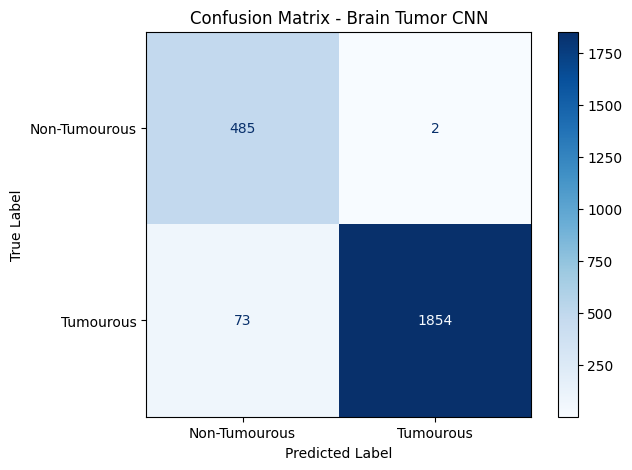

In [ ]:
# plot the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumourous", "Tumourous"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Brain Tumor CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)

plt.show()

                2,414 Test MRI Images
                         │
             ┌───────────┴───────────┐
             │                       │
       Non-Tumourous              Tumourous
          487 images              1,927 images
             │                       │
        485 correct              1,854 correct
          2 wrong                   73 missed

In [ ]:
# calculate and display key performance metrics

accuracy = accuracy_score(y_true, y_pred)

tumour_precision = precision_score(y_true, y_pred, pos_label=1)

tumour_recall = recall_score(y_true, y_pred, pos_label=1)

tumour_f1 = f1_score(y_true, y_pred, pos_label=1)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Tumourous Precision",
        "Tumourous Recall",
        "Tumourous F1-score"
    ],
    "Score": [
        accuracy,
        tumour_precision,
        tumour_recall,
        tumour_f1
    ]
})

metrics_df["Score (%)"] = metrics_df["Score"] * 100
metrics_df

,Metric,Score,Score (%)
0,Accuracy,0.968931,96.893123
1,Tumourous Precision,0.998922,99.892241
2,Tumourous Recall,0.962117,96.211728
3,Tumourous F1-score,0.980174,98.017446


In [ ]:
# record classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=["Non-Tumourous", "Tumourous"],
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

               precision    recall  f1-score   support

Non-Tumourous     0.8692    0.9959    0.9282       487
    Tumourous     0.9989    0.9621    0.9802      1927

     accuracy                         0.9689      2414
    macro avg     0.9340    0.9790    0.9542      2414
 weighted avg     0.9727    0.9689    0.9697      2414



In [ ]:
# save classification report to a text file

REPORT_PATH = os.path.join(RESULTS_DIR, "classification_report.txt")

with open(REPORT_PATH, "w") as f:
    f.write("Brain Tumor CNN - Classification Report\n")
    f.write("=" * 50 + "\n\n")
    f.write(report)

print("Classification report saved to:")
print(REPORT_PATH)

Classification report saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/classification_report.txt


In [ ]:
# save confusion matrix as CSV

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Tumourous", "Actual Tumourous"],
    columns=["Predicted Non-Tumourous", "Predicted Tumourous"]
)

CM_PATH = os.path.join(RESULTS_DIR, "confusion_matrix.csv")

cm_df.to_csv(CM_PATH)

print("Confusion matrix saved to:")
print(CM_PATH)

Confusion matrix saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/confusion_matrix.csv


In [ ]:
# save main test performance metrics

test_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Tumourous Precision": precision_score(y_true, y_pred),
    "Tumourous Recall": recall_score(y_true, y_pred),
    "Tumourous F1 Score": f1_score(y_true, y_pred)
}

metrics_df = pd.DataFrame([test_metrics])

METRICS_PATH = os.path.join(RESULTS_DIR, "test_metrics.csv")

metrics_df.to_csv(METRICS_PATH, index=False)

print("Test metrics saved to:")
print(METRICS_PATH)

print("\nTest Metrics:")
print(metrics_df)

Test metrics saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/test_metrics.csv

Test Metrics:
   Accuracy  Tumourous Precision  Tumourous Recall  Tumourous F1 Score
0  0.968931             0.998922          0.962117            0.980174


In [ ]:
# save test predictions for the evaluation notebook

prediction_results = pd.DataFrame({
    "image_path": test_df["image_path"].values,
    "true_label": y_true,
    "predicted_probability": y_prob.flatten(),
    "predicted_label": y_pred
})

PREDICTIONS_PATH = os.path.join(
    RESULTS_DIR,
    "test_predictions.csv"
)

prediction_results.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("Test predictions saved to:")
print(PREDICTIONS_PATH)

Test predictions saved to:
/content/drive/MyDrive/Brain_Tumor_CNN_Project/results/test_predictions.csv
